In [1]:


import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
import h5py
import hdf5plugin  # REQUIRED to have the compression plugins available
import numpy as np
from scipy import constants, interpolate
import copy
import glob
import re
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_rows', 1000)
from uvtools.plot import plot_antpos, plot_antclass
from hera_qm import ant_metrics, ant_class, xrfi
from hera_qm import ant_metrics, xrfi
from hera_cal import io, utils, redcal, apply_cal, datacontainer, abscal
from hera_filters import dspec
from IPython.display import display, HTML
import linsolve
import time
tstart = time.time()



In [2]:
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"

In [3]:


# parse omnical settings
OC_MAX_DIMS = int(os.environ.get("OC_MAX_DIMS", 4))
OC_MIN_DIM_SIZE = int(os.environ.get("OC_MIN_DIM_SIZE", 8))
OC_SKIP_OUTRIGGERS = os.environ.get("OC_SKIP_OUTRIGGERS", "FALSE").upper() == "TRUE"
OC_MIN_BL_LEN = float(os.environ.get("OC_MIN_BL_LEN", 1))
OC_MAX_BL_LEN = float(os.environ.get("OC_MAX_BL_LEN", 1e100))
OC_MAXITER = int(os.environ.get("OC_MAXITER", 50))
OC_MAX_RERUN = int(os.environ.get("OC_MAX_RERUN", 4))
OC_RERUN_MAXITER = int(os.environ.get("OC_MAXITER", 25))
OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE = float(os.environ.get("OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE", 1))
OC_USE_PRIOR_SOL = os.environ.get("OC_USE_PRIOR_SOL", "FALSE").upper() == "TRUE"
OC_PRIOR_SOL_FLAG_THRESH = float(os.environ.get("OC_PRIOR_SOL_FLAG_THRESH", .95))
OC_USE_GPU = os.environ.get("SAVE_RESULTS", "FALSE").upper() == "TRUE"

# parse RFI settings
RFI_DPSS_HALFWIDTH = float(os.environ.get("RFI_DPSS_HALFWIDTH", 300e-9))
RFI_NSIG = float(os.environ.get("RFI_NSIG", 4))



# print settings
for setting in [ 'OC_MAX_DIMS', 'OC_MIN_DIM_SIZE', 'OC_SKIP_OUTRIGGERS', 
                'OC_MIN_BL_LEN', 'OC_MAX_BL_LEN', 'OC_MAXITER', 'OC_MAX_RERUN', 'OC_RERUN_MAXITER', 
                'OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE', 'OC_USE_PRIOR_SOL', 'OC_PRIOR_SOL_FLAG_THRESH', 
                'OC_USE_GPU', 'RFI_DPSS_HALFWIDTH', 'RFI_NSIG']:
    print(f'{setting} = {eval(setting)}')

OC_MAX_DIMS = 4
OC_MIN_DIM_SIZE = 8
OC_SKIP_OUTRIGGERS = False
OC_MIN_BL_LEN = 1.0
OC_MAX_BL_LEN = 1e+100
OC_MAXITER = 50
OC_MAX_RERUN = 4
OC_RERUN_MAXITER = 25
OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE = 1.0
OC_USE_PRIOR_SOL = False
OC_PRIOR_SOL_FLAG_THRESH = 0.95
OC_USE_GPU = False
RFI_DPSS_HALFWIDTH = 3e-07
RFI_NSIG = 4.0


In [4]:
read_start = time.time()

##filter file
hd = io.HERAData("/net/sinatra/vault2/ntsikelelo/Data_H6C/zen.2459861.50015.sum.uvh5")

SUM_FILE="/net/sinatra/vault2/ntsikelelo/Data_H6C/zen.2459861.50015.sum.uvh5"
DIFF_FILE="/net/sinatra/vault2/ntsikelelo/Data_H6C/zen.2459861.50015.diff.uvh5"
hd_unfil = io.HERAData(SUM_FILE)
hd_diff = io.HERAData(DIFF_FILE)
times=hd_unfil.times[0:2]
freq_range=hd_unfil.freq_array

data_unfil, _, _ = hd_unfil.read(frequencies=freq_range, times=times)
diff_data, _, _ = hd_diff.read(frequencies=freq_range, times=times)
data, _, _ = hd.read(frequencies=freq_range,times=times)
print(f'Finished loading data in {(time.time() - read_start) / 60:.2f} minutes.')


Finished loading data in 3.40 minutes.


In [5]:
t=times

## Set FLAGGING Parameters

In [6]:
# ant_metrics bounds for low correlation / dead antennas
am_corr_bad = (0, float(os.environ.get("AM_CORR_BAD", 0.3)))
am_corr_suspect = (float(os.environ.get("AM_CORR_BAD", 0.3)), float(os.environ.get("AM_CORR_SUSPECT", 0.5)))

# ant_metrics bounds for cross-polarized antennas
am_xpol_bad = (-1, float(os.environ.get("AM_XPOL_BAD", -0.1)))
am_xpol_suspect = (float(os.environ.get("AM_XPOL_BAD", -0.1)), float(os.environ.get("AM_XPOL_SUSPECT", 0)))

# bounds on solar altitude (in degrees)
good_solar_altitude = (-90, float(os.environ.get("SUSPECT_SOLAR_ALTITUDE", 0)))
suspect_solar_altitude = (float(os.environ.get("SUSPECT_SOLAR_ALTITUDE", 0)), 90)

# bounds on zeros in spectra
good_zeros_per_eo_spectrum = (0, int(os.environ.get("MAX_ZEROS_PER_EO_SPEC_GOOD", 2)))
suspect_zeros_per_eo_spectrum = (0, int(os.environ.get("MAX_ZEROS_PER_EO_SPEC_SUSPECT", 8)))

# bounds on autocorrelation power
auto_power_good = (float(os.environ.get("AUTO_POWER_GOOD_LOW", 5)), float(os.environ.get("AUTO_POWER_GOOD_HIGH", 30)))
auto_power_suspect = (float(os.environ.get("AUTO_POWER_SUSPECT_LOW", 1)), float(os.environ.get("AUTO_POWER_SUSPECT_HIGH", 60)))

# bounds on autocorrelation slope
auto_slope_good = (float(os.environ.get("AUTO_SLOPE_GOOD_LOW", -0.4)), float(os.environ.get("AUTO_SLOPE_GOOD_HIGH", 0.4)))
auto_slope_suspect = (float(os.environ.get("AUTO_SLOPE_SUSPECT_LOW", -0.6)), float(os.environ.get("AUTO_SLOPE_SUSPECT_HIGH", 0.6)))

# bounds on autocorrelation RFI
auto_rfi_good = (0, float(os.environ.get("AUTO_RFI_GOOD", 1.5)))
auto_rfi_suspect = (0, float(os.environ.get("AUTO_RFI_SUSPECT", 2)))

# bounds on autocorrelation shape
auto_shape_good = (0, float(os.environ.get("AUTO_SHAPE_GOOD", 0.1)))
auto_shape_suspect = (0, float(os.environ.get("AUTO_SHAPE_SUSPECT", 0.2)))

# bound on per-xengine non-noiselike power in diff
bad_xengine_zcut = float(os.environ.get("BAD_XENGINE_ZCUT", 10.0))

# bounds on chi^2 per antenna in omnical
oc_cspa_good = (0, float(os.environ.get("OC_CSPA_GOOD", 2)))
oc_cspa_suspect = (0, float(os.environ.get("OC_CSPA_SUSPECT", 3)))

# print bounds
for bound in ['am_corr_bad', 'am_corr_suspect', 'am_xpol_bad', 'am_xpol_suspect', 
              'good_solar_altitude', 'suspect_solar_altitude',
              'good_zeros_per_eo_spectrum', 'suspect_zeros_per_eo_spectrum',
              'auto_power_good', 'auto_power_suspect', 'auto_slope_good', 'auto_slope_suspect',
              'auto_rfi_good', 'auto_rfi_suspect', 'auto_shape_good', 'auto_shape_suspect',
              'bad_xengine_zcut', 'oc_cspa_good', 'oc_cspa_suspect']:
    print(f'{bound} = {eval(bound)}')

am_corr_bad = (0, 0.3)
am_corr_suspect = (0.3, 0.5)
am_xpol_bad = (-1, -0.1)
am_xpol_suspect = (-0.1, 0.0)
good_solar_altitude = (-90, 0.0)
suspect_solar_altitude = (0.0, 90)
good_zeros_per_eo_spectrum = (0, 2)
suspect_zeros_per_eo_spectrum = (0, 8)
auto_power_good = (5.0, 30.0)
auto_power_suspect = (1.0, 60.0)
auto_slope_good = (-0.4, 0.4)
auto_slope_suspect = (-0.6, 0.6)
auto_rfi_good = (0, 1.5)
auto_rfi_suspect = (0, 2.0)
auto_shape_good = (0, 0.1)
auto_shape_suspect = (0, 0.2)
bad_xengine_zcut = 10.0
oc_cspa_good = (0, 2.0)
oc_cspa_suspect = (0, 3.0)


In [7]:
ants = sorted(set([ant for bl in hd.bls for ant in utils.split_bl(bl)]))
auto_bls = [bl for bl in data if (bl[0] == bl[1]) and (utils.split_pol(bl[2])[0] == utils.split_pol(bl[2])[1])]
antpols = sorted(set([ant[1] for ant in ants]))

## ANTENNA CLASSIFICATION

In [8]:
am = ant_metrics.AntennaMetrics(SUM_FILE, DIFF_FILE, sum_data=data_unfil, diff_data=diff_data)
am.iterative_antenna_metrics_and_flagging(crossCut=am_xpol_bad[1], deadCut=am_corr_bad[1])
am.all_metrics = {}  # this saves time and disk by getting rid of per-iteration information we never use

# Turn ant metrics into classifications
totally_dead_ants = [ant for ant, i in am.xants.items() if i == -1]
am_totally_dead = ant_class.AntennaClassification(good=[ant for ant in ants if ant not in totally_dead_ants], bad=totally_dead_ants)
am_corr = ant_class.antenna_bounds_checker(am.final_metrics['corr'], bad=[am_corr_bad], suspect=[am_corr_suspect], good=[(0, 1)])
am_xpol = ant_class.antenna_bounds_checker(am.final_metrics['corrXPol'], bad=[am_xpol_bad], suspect=[am_xpol_suspect], good=[(-1, 1)])
ant_metrics_class = am_totally_dead + am_corr + am_xpol
if np.all([ant_metrics_class[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged for ant_metrics.')

min_sun_alt = np.min(utils.get_sun_alt(hd.times))
solar_class = ant_class.antenna_bounds_checker({ant: min_sun_alt for ant in ants}, good=[good_solar_altitude], suspect=[suspect_solar_altitude])

zeros_class = ant_class.even_odd_zeros_checker(data_unfil, diff_data, good=good_zeros_per_eo_spectrum, suspect=suspect_zeros_per_eo_spectrum)
if np.all([zeros_class[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged for too many even/odd zeros.')
    
auto_power_class = ant_class.auto_power_checker(data_unfil, good=auto_power_good, suspect=auto_power_suspect)
if np.all([(auto_power_class)[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged for bad autocorrelation power/slope.')
overall_class = auto_power_class  + zeros_class + ant_metrics_class + solar_class    


All-NaN slice encountered


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


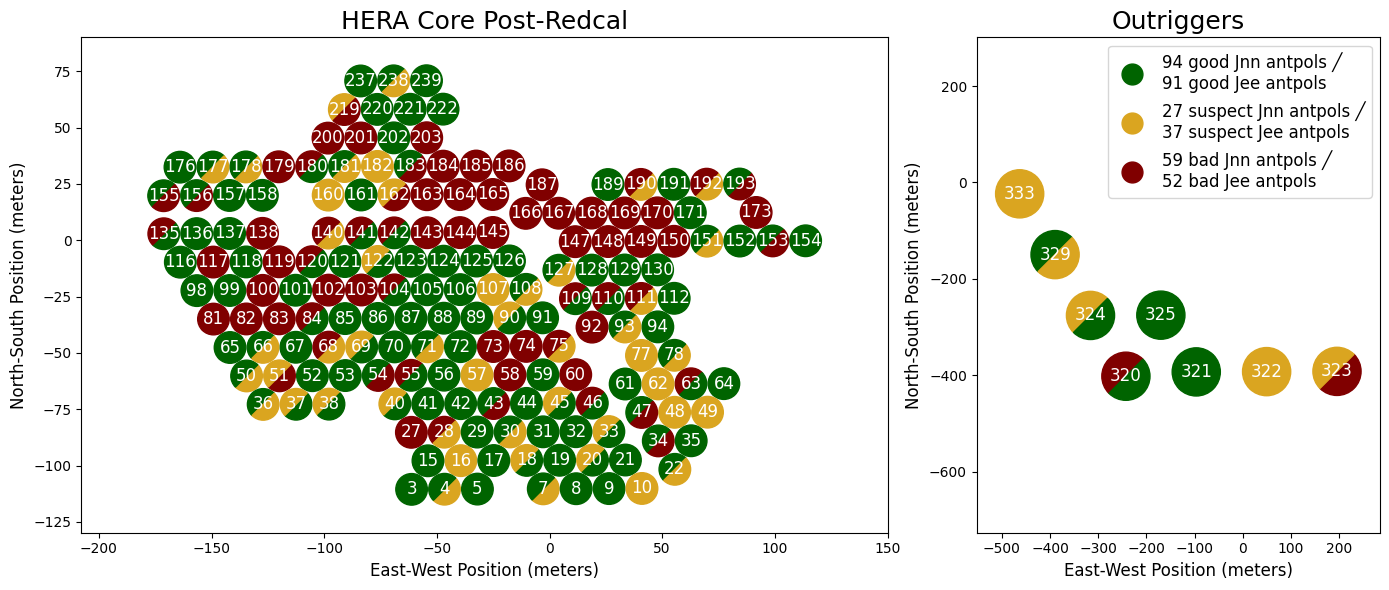

In [9]:
def array_class_plot(cls, extra_label=""):
    outriggers = [ant for ant in hd.data_ants if ant >= 320]

    if len(outriggers) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100, gridspec_kw={'width_ratios': [2, 1]})
        plot_antclass(hd.antpos, cls, ax=axes[0], ants=[ant for ant in hd.data_ants if ant < 320], legend=False, title=f'HERA Core{extra_label}')
        plot_antclass(hd.antpos, cls, ax=axes[1], ants=outriggers, radius=50, title='Outriggers')
    else:
        fig, axes = plt.subplots(1, 1, figsize=(9, 6), dpi=100)
        plot_antclass(hd.antpos, cls, ax=axes, ants=[ant for ant in hd.data_ants if ant < 320], legend=False, title=f'HERA Core{extra_label}')
        

array_class_plot(overall_class, extra_label=" Post-Redcal")

## RFI FLAGGING

In [10]:
def auto_bl_zscores(data, flag_array, cache={}):
    '''This function computes z-score arrays for each delay-filtered autocorrelation, normalized by the expected noise. 
    Flagged times/channels for the whole array are given 0 weight in filtering and are np.nan in the z-score.'''
    zscores = {}
    for bl in auto_bls:
        wgts = np.array(np.logical_not(flag_array), dtype=np.float64)
        model, _, _ = dspec.fourier_filter(data.freqs, data[bl], wgts, filter_centers=[0], filter_half_widths=[RFI_DPSS_HALFWIDTH], mode='dpss_solve',
                                            suppression_factors=[1e-9], eigenval_cutoff=[1e-9], cache=cache)
        res = data[bl] - model
        int_time = 24 * 3600 * np.median(np.diff(data.times))
        chan_res = np.median(np.diff(data.freqs))
        int_count = int(int_time * chan_res)
        sigma = np.abs(model) / np.sqrt(int_count / 2)
        zscores[bl] = res / sigma    
        zscores[bl][flag_array] = np.nan

    return zscores

def rfi_from_avg_autos(data, auto_bls_to_use, prior_flags=None, nsig=RFI_NSIG):
    '''Average together all baselines in auto_bls_to_use, then find an RFI mask by looking for outliers after DPSS filtering.'''
    
    # Compute int_count for all unflagged autocorrelations averaged together
    int_time = 24 * 3600 * np.median(np.diff(data.times_by_bl[auto_bls[0][0:2]]))
    chan_res = np.median(np.diff(data.freqs))
    int_count = int(int_time * chan_res) * len(auto_bls_to_use)
    avg_auto = {(-1, -1, 'ee'): np.mean([data[bl] for bl in auto_bls_to_use], axis=0)}
    
    # Flag RFI first with channel differences and then with DPSS
    antenna_flags, _ = xrfi.flag_autos(avg_auto, int_count=int_count, nsig=(RFI_NSIG * 5))
    if prior_flags is not None:
        antenna_flags[(-1, -1, 'ee')] = prior_flags
    _, rfi_flags = xrfi.flag_autos(avg_auto, int_count=int_count, flag_method='dpss_flagger',
                                   flags=antenna_flags, freqs=data.freqs, filter_centers=[0],
                                   filter_half_widths=[RFI_DPSS_HALFWIDTH], eigenval_cutoff=[1e-9], nsig=nsig)

    return rfi_flags    



antenna_flags, array_flags = xrfi.flag_autos(data_unfil, flag_method="channel_diff_flagger", nsig=RFI_NSIG * 5, 
                                             antenna_class=overall_class, flag_broadcast_thresh=.5)
for key in antenna_flags:
    antenna_flags[key] = array_flags
cache = {}
_, array_flags = xrfi.flag_autos(data_unfil, freqs=data_unfil.freqs, flag_method="dpss_flagger",
                                 nsig=RFI_NSIG, antenna_class=overall_class,
                                 filter_centers=[0], filter_half_widths=[RFI_DPSS_HALFWIDTH],
                                 eigenval_cutoff=[1e-9], flags=antenna_flags, mode='dpss_matrix', 
                                 cache=cache, flag_broadcast_thresh=.5)

xengine_diff_class = ant_class.non_noiselike_diff_by_xengine_checker(data_unfil, diff_data, flag_waterfall=array_flags, 
                                                                     antenna_class=overall_class, 
                                                                     xengine_chans=1, bad_xengine_zcut=bad_xengine_zcut)
overall_class += xengine_diff_class
if np.all([overall_class[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged after flagging non-noiselike diffs.')


# Iteratively develop RFI mask, excess RFI classification, and autocorrelation shape classification
stage = 1
rfi_flags = np.array(array_flags)
prior_end_states = set()
while True:
    print(stage)
    # compute DPSS-filtered z-scores with current array-wide RFI mask
    zscores = auto_bl_zscores(data_unfil, rfi_flags)
    rms = {bl: np.nanmean(zscores[bl]**2)**.5 if np.any(np.isfinite(zscores[bl])) else np.inf for bl in zscores}
    
    # figure out which autos to use for finding new set of flags
    candidate_autos = [bl for bl in auto_bls if overall_class[utils.split_bl(bl)[0]] != 'bad']
    if stage == 1:
        # use best half of the unflagged antennas
        med_rms = np.nanmedian([rms[bl] for bl in candidate_autos])
        autos_to_use = [bl for bl in candidate_autos if rms[bl] <= med_rms]
    elif stage == 2:
        # use all unflagged antennas which are auto RFI good, or the best half, whichever is larger
        med_rms = np.nanmedian([rms[bl] for bl in candidate_autos])
        best_half_autos = [bl for bl in candidate_autos if rms[bl] <= med_rms]
        good_autos = [bl for bl in candidate_autos if (overall_class[utils.split_bl(bl)[0]] != 'bad')
                      and (auto_rfi_class[utils.split_bl(bl)[0]] == 'good')]
        autos_to_use = (best_half_autos if len(best_half_autos) > len(good_autos) else good_autos)
    elif stage == 3:
        # use all unflagged antennas which are auto RFI good or suspect
        autos_to_use = [bl for bl in candidate_autos if (overall_class[utils.split_bl(bl)[0]] != 'bad')]

    # compute new RFI flags
    rfi_flags = rfi_from_avg_autos(data_unfil, autos_to_use)

    # perform auto shape and RFI classification
    overall_class = auto_power_class  + zeros_class + ant_metrics_class + solar_class + xengine_diff_class
    auto_rfi_class = ant_class.antenna_bounds_checker(rms, good=auto_rfi_good, suspect=auto_rfi_suspect, bad=(0, np.inf))
    overall_class += auto_rfi_class
    auto_shape_class = ant_class.auto_shape_checker(data_unfil, good=auto_shape_good, suspect=auto_shape_suspect,
                                                    flag_spectrum=np.sum(rfi_flags, axis=0).astype(bool), 
                                                    antenna_class=overall_class)
    overall_class += auto_shape_class
    
    # check for convergence by seeing whether we've previously gotten to this number of flagged antennas and channels
    if stage == 3:
        if (len(overall_class.bad_ants), np.sum(rfi_flags)) in prior_end_states:
            break
        prior_end_states.add((len(overall_class.bad_ants), np.sum(rfi_flags)))
    else:
        stage += 1


auto_class = auto_power_class + auto_rfi_class + auto_shape_class
if np.all([overall_class[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged after flagging for bad autos power/slope/rfi/shape.')        

invalid value encountered in multiply
invalid value encountered in multiply
Mean of empty slice
divide by zero encountered in divide


1


invalid value encountered in divide
invalid value encountered in divide
Mean of empty slice


2
3
3
3


In [11]:
def rfi_plot(cls, flags=rfi_flags, data=data):
    avg_auto = {(-1, -1, 'ee'): np.mean([data[bl] for bl in auto_bls if not cls[utils.split_bl(bl)[0]] == 'bad'], axis=0)}
    plt.figure(figsize=(12, 5), dpi=100)
    plt.semilogy(data.freqs / 1e6, np.where(flags, np.nan, avg_auto[(-1, -1, 'ee')])[0], label = 'Average Good or Suspect Autocorrelation', zorder=100)
    plt.semilogy(data.freqs / 1e6, np.where(False, np.nan, avg_auto[(-1, -1, 'ee')])[0], 'r', lw=.5, label=f'{np.sum(flags[0])} Channels Flagged for RFI')
    plt.legend()
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('Uncalibrated Autocorrelation')
    plt.tight_layout()

Casting complex values to real discards the imaginary part
Casting complex values to real discards the imaginary part


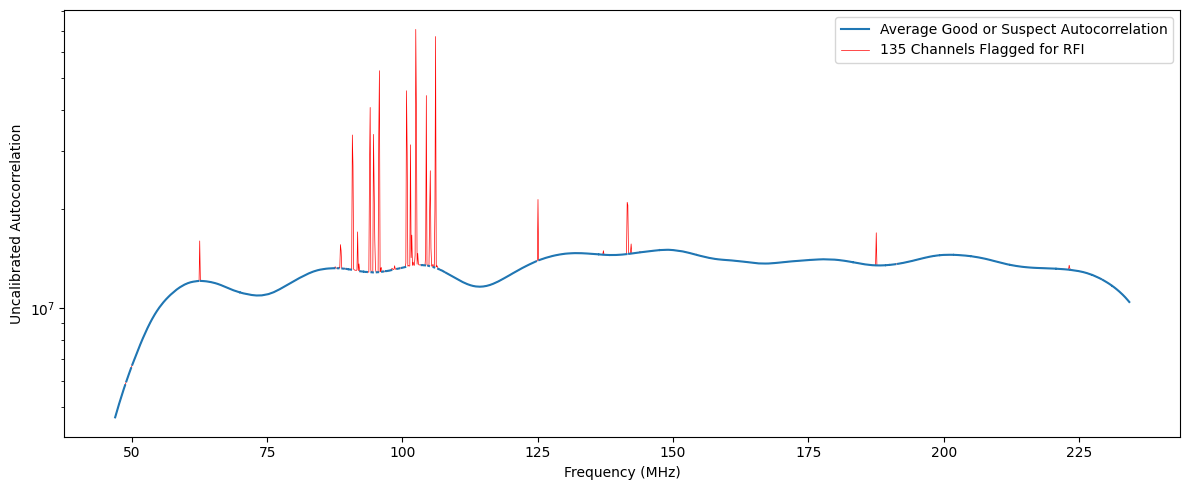

In [12]:
rfi_plot(cls=overall_class, flags=rfi_flags, data=data_unfil)

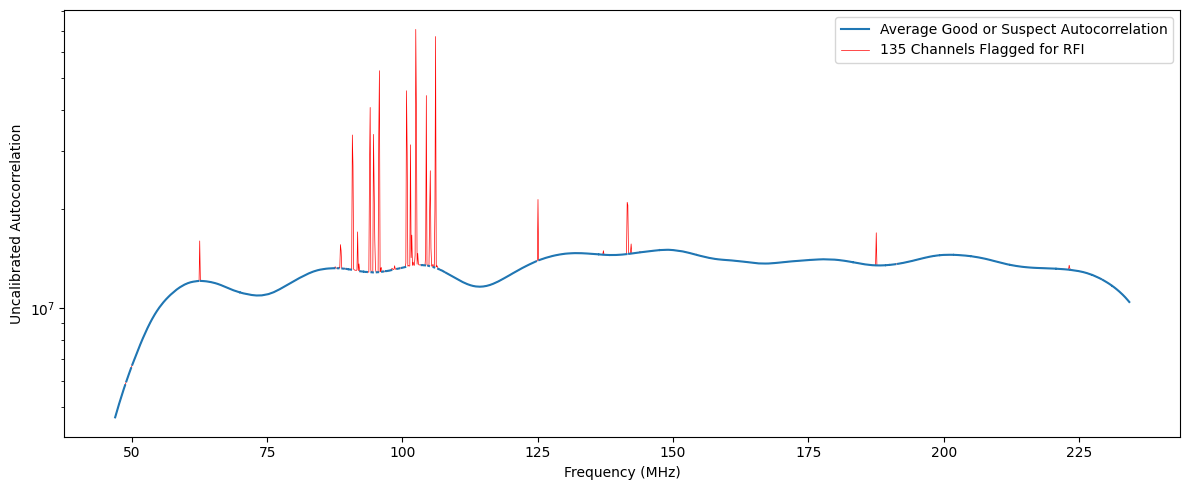

In [13]:
rfi_plot(cls=overall_class, flags=rfi_flags, data=data)

In [14]:
def autocorr_plot(cls, data=data):    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100, sharey=True, gridspec_kw={'wspace': 0})
    labels = []
    colors = ['darkgreen', 'goldenrod', 'maroon']
    for ax, pol in zip(axes, antpols):
        for ant in cls.ants:
            if ant[1] == pol:
                color = colors[cls.quality_classes.index(cls[ant])]
                ax.semilogy(np.mean(data[utils.join_bl(ant, ant)], axis=0), color=color, lw=.5)
        ax.set_xlabel('Channel', fontsize=12)
        ax.set_title(f'{utils.join_pol(pol, pol)}-Polarized Autos')

    axes[0].set_ylabel('Raw Autocorrelation', fontsize=12)
    axes[1].legend([matplotlib.lines.Line2D([0], [0], color=color) for color in colors], 
                   [cl.capitalize() for cl in cls.quality_classes], ncol=1, fontsize=12, loc='upper right', framealpha=1)

In [15]:
def array_class_plot(cls, extra_label=""):
    outriggers = [ant for ant in hd.data_ants if ant >= 320]

    if len(outriggers) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100, gridspec_kw={'width_ratios': [2, 1]})
        plot_antclass(hd.antpos, cls, ax=axes[0], ants=[ant for ant in hd.data_ants if ant < 320], legend=False, title=f'HERA Core{extra_label}')
        plot_antclass(hd.antpos, cls, ax=axes[1], ants=outriggers, radius=50, title='Outriggers')
    else:
        fig, axes = plt.subplots(1, 1, figsize=(9, 6), dpi=100)
        plot_antclass(hd.antpos, cls, ax=axes, ants=[ant for ant in hd.data_ants if ant < 320], legend=False, title=f'HERA Core{extra_label}')



In [16]:

def array_class_plot_2(cls, extra_label=""):
    outriggers = [ant for ant in hd.data_ants if ant >= 320]

    if len(outriggers) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100, gridspec_kw={'width_ratios': [2, 1]})
        plot_antclass(hd.antpos, cls, ax=axes[0], ants=[ant for ant in hd.data_ants if ant < 320], legend=False, title=f'HERA Core{extra_label}')
        plot_antclass(hd.antpos, cls, ax=axes[1], ants=outriggers, radius=50, title='Outriggers')
    else:
        fig, axes = plt.subplots(1, 1, figsize=(9, 6), dpi=100)
        plot_antclass(hd.antpos, cls, ax=axes, ants=[ant for ant in hd.data_ants if ant < 320], legend=False, title=f'HERA Core{extra_label}')
    fig.savefig("paper_figures/array_outline.pdf")


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


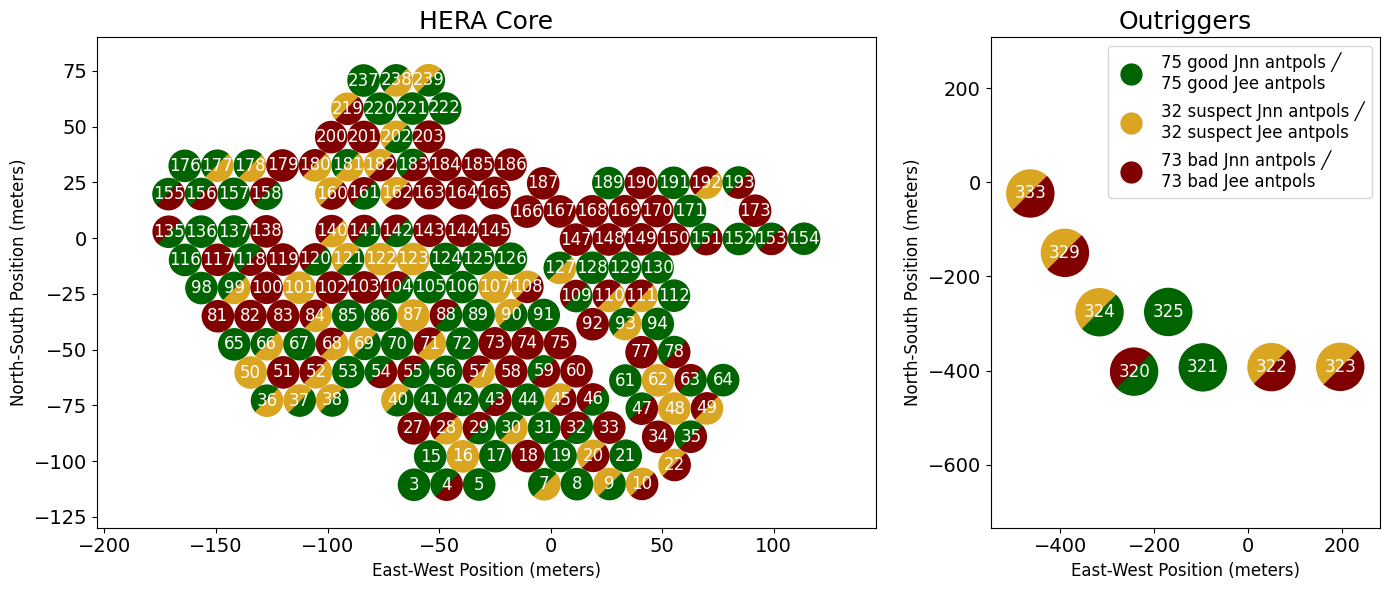

In [17]:
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=14)
array_class_plot(overall_class)


In [18]:
# plt.rc('xtick', labelsize=40)    # fontsize of the tick labels
# plt.rc('ytick', labelsize=40)
# fig, ax = plt.subplots(figsize=(25, 15))
# antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
# for i, a in enumerate(ants):
#     if a<300:
#         # print(i)
#         ax.scatter(antpos[i,0], antpos[i,1], s=1200, fc='w', ec='k')
#         ax.text(antpos[i,0]-2, antpos[i,1], a, fontsize=12)
# ax.set_xlabel('East position [m]', fontsize=16); ax.set_ylabel('North position [m]', fontsize=16)

# fig.savefig("paper_figures/array_inner.pdf")

# fig, ax = plt.subplots(figsize=(25, 15))
# for i, a in enumerate(ants):
#     if a>300:
#         # print(i)
#         ax.scatter(antpos[i,0], antpos[i,1], s=1200, fc='w', ec='k')
#         ax.text(antpos[i,0]-5, antpos[i,1], a, fontsize=12)
# ax.set_xlabel('East position [m]', fontsize=16); ax.set_ylabel('North position [m]', fontsize=16)
# fig.savefig("paper_figures/array_outer.pdf")


## Perform redundant cal

In [19]:
def classify_off_grid(reds, all_ants):
    '''Returns AntennaClassification of all_ants where good ants are in reds while bad ants are not.'''
    ants_in_reds = set([ant for red in reds for bl in red for ant in utils.split_bl(bl)])
    on_grid = [ant for ant in all_ants if ant in ants_in_reds]
    off_grid = [ant for ant in all_ants if ant not in ants_in_reds]
    return ant_class.AntennaClassification(good=on_grid, bad=off_grid)

def per_pol_filter_reds(reds, pols=['nn', 'ee'], **kwargs):
    '''Performs redcal filtering separately on polarizations (which might have different min_dim_size issues).'''
    return [red for pol in pols for red in redcal.filter_reds(copy.deepcopy(reds), pols=[pol], **kwargs)]  

def check_if_whole_pol_flagged(redcal_class, pols=['Jee', 'Jnn']):
    '''Checks if an entire polarization is flagged. If it is, returns True and marks all antennas as bad in redcal_class.'''
    if np.logical_or(*[np.all([redcal_class[ant] == 'bad' for ant in redcal_class.ants if ant[1] == pol]) for pol in pols]):
        print('An entire polarization has been flagged. Stopping redcal.')
        for ant in redcal_class:
            redcal_class[ant] = 'bad'
        return True
    return False    


def recheck_chisq(cspa, sol, cutoff, avg_alg):
    '''Recompute chisq per ant without apparently bad antennas to see if any antennas get better.'''
    avg_cspa = {ant: avg_alg(np.where(rfi_flags, np.nan, cspa[ant])) for ant in cspa}
    sol2 = redcal.RedSol(sol.reds, gains={ant: sol[ant] for ant in avg_cspa if avg_cspa[ant] <= cutoff}, vis=sol.vis)
    new_chisq_per_ant = {ant: np.array(cspa[ant]) for ant in sol2.gains}
    if len(set([bl[2] for red in per_pol_filter_reds(sol2.reds, ants=sol2.gains.keys(), antpos=hd.data_antpos, **fr_settings) for bl in red])) >= 2:
        redcal.expand_omni_gains(sol2, sol2.reds, data, chisq_per_ant=new_chisq_per_ant)
    for ant in avg_cspa:
        if ant in new_chisq_per_ant:
            if np.any(np.isfinite(new_chisq_per_ant[ant])):
                if not np.all(np.isclose(new_chisq_per_ant[ant], 0)):
                    new_avg_cspa = avg_alg(np.where(rfi_flags, np.nan, cspa[ant]))
                    if new_avg_cspa > 0:
                        avg_cspa[ant] = np.min([avg_cspa[ant], new_avg_cspa])
    return avg_cspa

import ctypes
def malloc_trim():
    try:
        ctypes.CDLL('libc.so.6').malloc_trim(0) 
    except OSError:
        pass


## Redundant calibration 

In [20]:
# this enables better memory management on linux
def redundant_calibration (data, redcal_class, overall_class, reds):

    redcal_start = time.time()
    rc_settings = {'max_dims': OC_MAX_DIMS, 'oc_conv_crit': 1e-10, 'gain': 0.4, 'run_logcal': False,
                   'oc_maxiter': OC_MAXITER, 'check_after': OC_MAXITER, 'use_gpu': OC_USE_GPU}
    
    if check_if_whole_pol_flagged(redcal_class):
        # skip redcal, initialize empty sol and meta 
        sol = redcal.RedSol(reds)
        meta = {'chisq': None, 'chisq_per_ant': None}
    else:    
            # perform first stage of redundant calibration 
            meta, sol = redcal.redundantly_calibrate(data, reds, **rc_settings)
        
            max_dly = np.max(np.abs(list(meta['fc_meta']['dlys'].values())))  # Needed for RFI delay-slope cal
            median_cspa = recheck_chisq(meta['chisq_per_ant'], sol, oc_cspa_suspect[1] * 5, np.nanmedian)
        
             # remove particularly bad antennas (5x the bound on median, not mean)
            cspa_class = ant_class.antenna_bounds_checker(median_cspa, good=(oc_cspa_good[0], oc_cspa_suspect[1] * 5), bad=[(-np.inf, np.inf)])
            redcal_class += cspa_class
            print(f'Removing {cspa_class.bad_ants} for >5x high median chi^2.')
            for ant in cspa_class.bad_ants:
                print(f'\t{ant}: {median_cspa[ant]:.3f}')
    
    
            # iteratively rerun redundant calibration
    redcal_done = False
    rc_settings['oc_maxiter'] = rc_settings['check_after'] = OC_RERUN_MAXITER
    for i in range(OC_MAX_RERUN + 1-OC_MAX_RERUN ):
        # refilter reds and update classification to reflect new off-grid ants, if any
        reds = per_pol_filter_reds(reds, ex_ants=(overall_class + redcal_class).bad_ants, antpos=hd.data_antpos, **fr_settings)
        reds = sorted(reds, key=len, reverse=True)
        redcal_class += classify_off_grid(reds, ants)
        ants_in_reds = set([ant for red in reds for bl in red for ant in utils.split_bl(bl)])
        
        # check to see whether we're done
        if check_if_whole_pol_flagged(redcal_class) or redcal_done or (i == OC_MAX_RERUN):
            break
    
        # re-run redundant calibration using previous solution, updating bad and suspicious antennas
        meta, sol = redcal.redundantly_calibrate(data, reds, sol0=sol, **rc_settings)
        malloc_trim()
        
        # recompute chi^2 for bad antennas without bad antennas to make sure they are actually bad
        mean_cspa = recheck_chisq(meta['chisq_per_ant'], sol, oc_cspa_suspect[1], np.nanmean)
        
        # remove bad antennas
        cspa_class = ant_class.antenna_bounds_checker(mean_cspa, good=oc_cspa_good, suspect=oc_cspa_suspect, bad=[(-np.inf, np.inf)])
        for ant in cspa_class.bad_ants:
            if mean_cspa[ant] < np.max(list(mean_cspa.values())) / OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE:
                cspa_class[ant] = 'suspect'  # reclassify as suspect if they are much better than the worst antennas
        redcal_class += cspa_class
        print(f'Removing {cspa_class.bad_ants} for high mean unflagged chi^2.')
        for ant in cspa_class.bad_ants:
            print(f'\t{ant}: {mean_cspa[ant]:.3f}')
    
        if len(cspa_class.bad_ants) == 0:
            redcal_done = True  # no new antennas to flag
    
    print(f'Finished redcal in {(time.time() - redcal_start) / 60:.2f} minutes.')
    overall_class += redcal_class
    
    expanded_reds = redcal.get_reds(hd.data_antpos, pols=['ee', 'nn'], pol_mode='2pol')
    expanded_reds = per_pol_filter_reds(expanded_reds, ex_ants=(ant_metrics_class + solar_class + zeros_class + auto_class + xengine_diff_class).bad_ants,
                                        max_dims=OC_MAX_DIMS, min_dim_size=OC_MIN_DIM_SIZE)
    if OC_SKIP_OUTRIGGERS:
        expanded_reds = redcal.filter_reds(expanded_reds, ex_ants=[ant for ant in ants if ant[0] >= 320])
    if len(sol.gains) > 0:
        redcal.expand_omni_vis(sol, expanded_reds, data, chisq=meta['chisq'], chisq_per_ant=meta['chisq_per_ant'])
    
    # now figure out flags, nsamples etc.
    omni_flags = {ant: (~np.isfinite(g)) | (ant in overall_class.bad_ants) for ant, g in sol.gains.items()}
    vissol_flags = datacontainer.RedDataContainer({bl: ~np.isfinite(v) for bl, v in sol.vis.items()}, reds=sol.vis.reds)
    single_nsamples_array = np.ones((len(data.times), len(data.freqs)), dtype=float)
    nsamples = datacontainer.DataContainer({bl: single_nsamples_array for bl in data})
    vissol_nsamples = redcal.count_redundant_nsamples(nsamples, [red for red in expanded_reds if red[0] in vissol_flags], 
                                                      good_ants=[ant for ant in overall_class if ant not in overall_class.bad_ants])
    for bl in vissol_flags:
        vissol_flags[bl][vissol_nsamples[bl] == 0] = True
    sol.make_sol_finite()
    
    return sol, meta, overall_class, vissol_flags

In [21]:
# figure out and filter reds and classify antennas based on whether or not they are on the main grid
fr_settings = {'max_dims': OC_MAX_DIMS, 'min_dim_size': OC_MIN_DIM_SIZE, 'min_bl_cut': OC_MIN_BL_LEN, 'max_bl_cut': OC_MAX_BL_LEN}
reds = redcal.get_reds(hd.data_antpos, pols=['ee', 'nn'], pol_mode='2pol')
reds = per_pol_filter_reds(reds, ex_ants=overall_class.bad_ants, antpos=hd.data_antpos, **fr_settings)
if OC_SKIP_OUTRIGGERS:
    reds = redcal.filter_reds(reds, ex_ants=[ant for ant in ants if ant[0] >= 320])
redcal_class = classify_off_grid(reds, ants)        
    
sol, meta, overall_class, vissol_flags=redundant_calibration (data, redcal_class, overall_class, reds)

Removing set() for >5x high median chi^2.
Removing {(28, 'Jee')} for high mean unflagged chi^2.
	(28, 'Jee'): 5.321
Finished redcal in 19.66 minutes.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


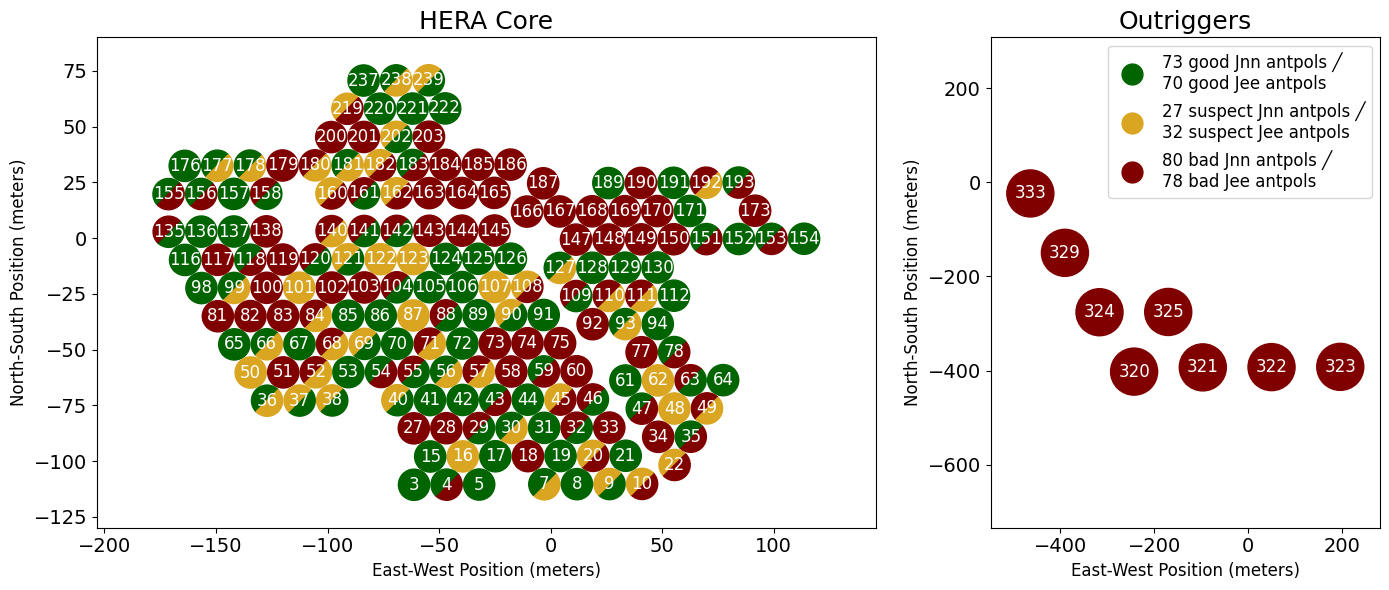

In [22]:
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=14)
array_class_plot(overall_class)
plt.savefig("paper_figures/array_outline.pdf")

In [23]:
# np.save(path_data+"gains/gains_redcal_"+uvh5name[i]+".npy",sol.gains)
# chis_redcal=np.where(rfi_flags, np.nan, meta['chisq']['Jnn']).ravel()
# np.save(path_data+"chisq/chisq_redcal_"+uvh5name[i]+".npy",chis_redcal)
hd.update(data=sol.vis)
hd.write_uvh5(path_data+"redundant_cal_data_temp_single_time.uvh5", clobber=True)

File exists; clobbering


In [24]:
def array_chisq_plot(include_outriggers=True):
    if np.all([ant in overall_class.bad_ants for ant in ants]):
        print('All antennas classified as bad. Nothing to plot.')
        return    
    
    def _chisq_subplot(ants, size=250):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
        for ax, pol in zip(axes, ['ee', 'nn']):
            ants_to_plot = set([ant for ant in meta['chisq_per_ant'] if utils.join_pol(ant[1], ant[1]) == pol and (ant[0] in ants)])
            cspas = np.array([np.nanmean(np.where(rfi_flags, np.nan, meta['chisq_per_ant'][ant])) for ant in ants_to_plot])
            xpos = [hd.antpos[ant[0]][0] for ant in ants_to_plot]
            ypos = [hd.antpos[ant[0]][1] for ant in ants_to_plot]
            scatter = ax.scatter(xpos, ypos, s=size, c=cspas, lw=.25, edgecolors=np.where(np.isfinite(cspas) & (cspas > 0), 'none', 'k'), 
                                 norm=matplotlib.colors.LogNorm(vmin=1, vmax=oc_cspa_suspect[1]))
            for ant in ants_to_plot:
                ax.text(hd.antpos[ant[0]][0], hd.antpos[ant[0]][1], ant[0], va='center', ha='center', fontsize=8,
                        c=('r' if ant in overall_class.bad_ants else 'w'))
            plt.colorbar(scatter, ax=ax, extend='both')
            ax.axis('equal')
            ax.set_xlabel('East-West Position (meters)')
            ax.set_ylabel('North-South Position (meters)')
            ax.set_title(f'{pol}-pol $\\chi^2$ / Antenna (Red is Flagged)')
        plt.tight_layout()    
    
    _chisq_subplot([ant for ant in hd.data_ants if ant < 320])
    outriggers = [ant for ant in hd.data_ants if ant >= 320]    
    if include_outriggers & (len(outriggers) > 0):
        _chisq_subplot([ant for ant in hd.data_ants if ant >= 320], size=400)


In [25]:


# plt.plot(chis_redcal)

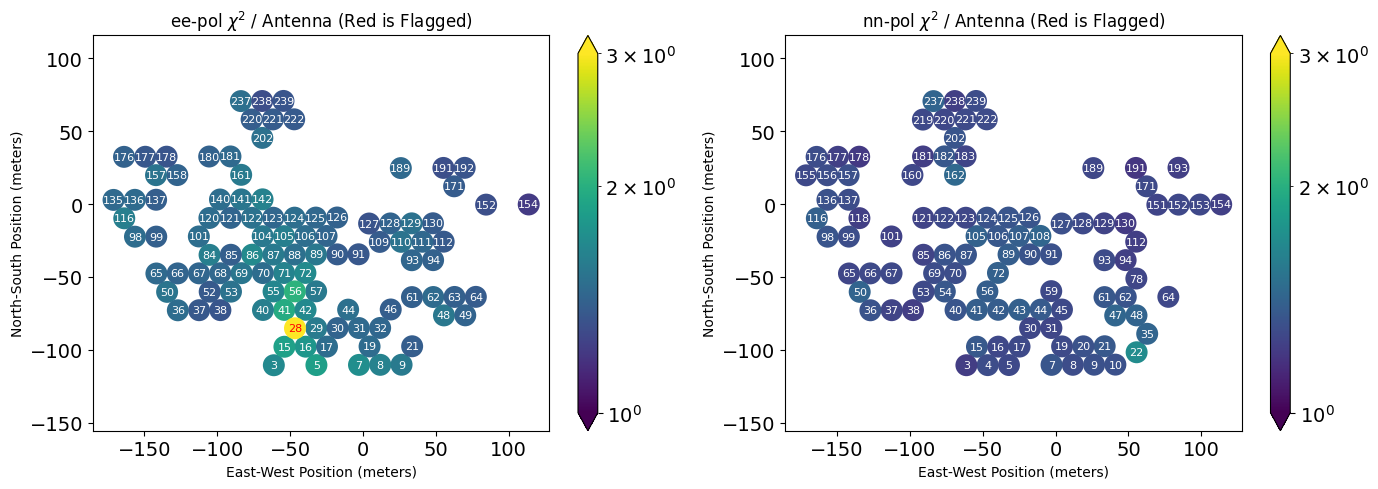

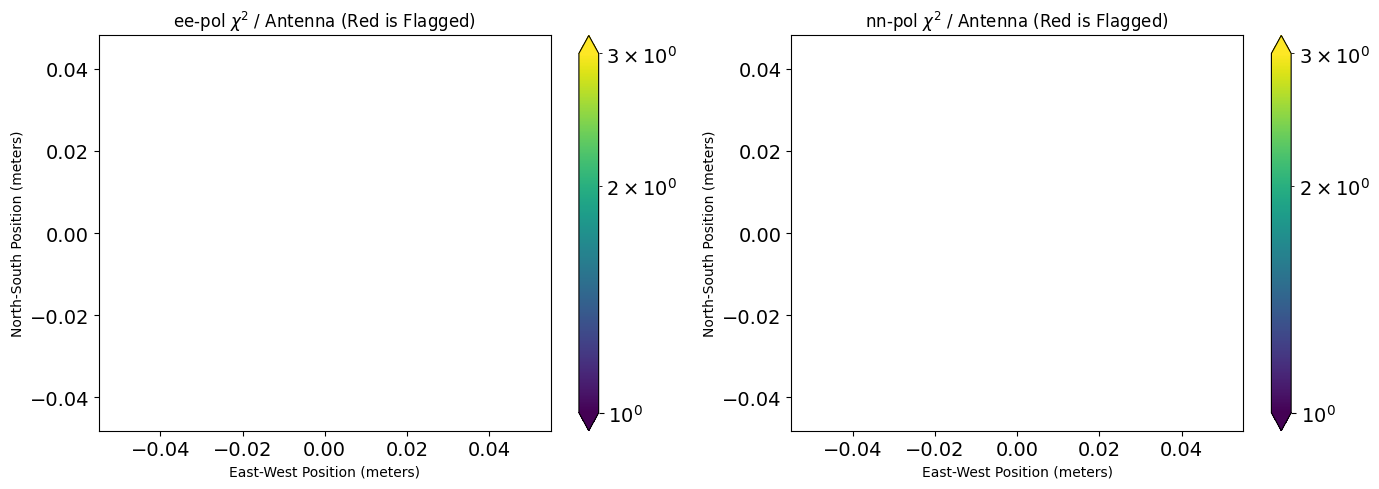

In [26]:
array_chisq_plot(include_outriggers=(not OC_SKIP_OUTRIGGERS))

In [27]:

def produce_model_data(mode="full_sky_model", freqs=freq_range, times=times):
    hdm_gleam = io.HERAData(path_data+"Single_time_Model_gleam_vis_expanded.uvh5")
    hdm_gleam.read(times=times, frequencies=freqs)
    model_data_gleam,_,_=hdm_gleam.build_datacontainers()
    
    hdm_diffuse = io.HERAData(path_data+"Single_time_Model_diffuse_vis_expanded.uvh5")
    hdm_diffuse.read(times=times, frequencies=freqs)
    model_data_diffuse,_,_=hdm_diffuse.build_datacontainers()
    
    if mode=="gleam_only":
        model_data=copy.deepcopy(model_data_gleam)
    if mode=="full_sky_model":
        model_data=copy.deepcopy(model_data_gleam)
        for bl in model_data:
            model_data[bl]=model_data[bl]+model_data_diffuse[bl]
    return model_data 
    
hdm_gleam = io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/Single_time_Model_gleam_vis_expanded.uvh5")
freq_range_reduced=freq_range[np.where( (hdm_gleam.freqs[0]<=freq_range) & (freq_range <=hdm_gleam.freqs[-1]))]
indexfreq=np.where( (hdm_gleam.freqs[0]<=freq_range) & (freq_range <=hdm_gleam.freqs[-1]))[0]
model_data_expanded_data=produce_model_data(mode="gleam_only", freqs=freq_range_reduced, times=times[0])

reds_here = redcal.get_reds(hd.data_antpos, pols=['nn'], pol_mode='1pol')
reds_filtered = per_pol_filter_reds(reds_here, ex_ants=overall_class.bad_ants, antpos=hd.data_antpos, **fr_settings)
all_bls=[]
for rg in reds_filtered:
            for bl in rg:
                all_bls.append(bl)

matched_bls=[]
for key in all_bls:
    if key in model_data_expanded_data.keys():
        matched_bls.append(key)

hd_cal= io.HERAData(path_data+"redundant_cal_data_temp_single_time.uvh5")
hd_cal.read(bls=matched_bls, frequencies=freq_range_reduced)
redcal_data,_,_=hd_cal.build_datacontainers()

hd_data= io.HERAData(SUM_FILE)
hd_data.read(bls=matched_bls, frequencies=freq_range_reduced)
data_reduced,_,_=hd_data.build_datacontainers()


In [28]:
hdm_gleam = io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/Single_time_Model_gleam_vis_expanded.uvh5")
hdm_gleam.times

array([2459861.50009578, 2459861.50020763])

In [49]:
def abscal_post_red_cal(data, model_data, redcal_data, redcal_gains, rfi_flags, hd):
    antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
    antpos_d = dict(zip(ants, antpos))
    #choose only baselines in data in model
    model_data_modi=copy.deepcopy(redcal_data)
    for k in redcal_data.keys():
            model_data_modi[k]=np.array(model_data[k])
    
    gain_cal_pol={}
    for k in redcal_gains:
        if k[1]=='Jnn':
            gain_cal_pol[k]=redcal_gains[k]
    
    rc_flags = {k: np.zeros_like(gain_cal_pol[k], dtype=bool) for k in gain_cal_pol}

    #get waterfall flags
    # there is a per frequency slove so rfi should not be a problem
    for ant in rc_flags:
        rc_flags[ant]=rfi_flags
           

        
    noise_wgts = {k: np.ones_like(redcal_data[k], dtype=float)  for k in redcal_data}
    n_cut=0
    for k in noise_wgts:

        blvec = (antpos[np.where(ants==k[0])][0] - antpos[np.where(ants==k[1])][0])

        bl_len_EW = np.linalg.norm(blvec)

        if bl_len_EW <30: 
            n_cut+=1

            noise_wgts[k] = np.ones(noise_wgts[k].shape)*1e-40
    # calibration with lincal gains

    print("number of baseline cuts in "+str(n_cut))
    calibrated_data = copy.deepcopy(redcal_data)
    
    #calibrated data gets modified but it is not fully calibrated!

    abscal_gains = abscal.post_redcal_abscal(model_data_modi, calibrated_data, noise_wgts, rc_flags, verbose=False, use_abs_amp_lincal=False)
            
    total_gains = abscal.merge_gains([gain_cal_pol, abscal_gains])
    raw_data_final = copy.deepcopy(data)
    abscal.calibrate_in_place(raw_data_final, total_gains)
    red_chisq=0

    
    # data_final_zero_padded=copy.deepcopy(data)
    # model_data_zero_padded=copy.deepcopy(model_data_modi)
    # for bl in data_final_zero_padded:

    #     data_final_zero_padded[bl][rfi_flags]=np.zeros(data_final_zero_padded[bl][rfi_flags].shape)
    #     model_data_zero_padded[bl][rfi_flags]=np.zeros(data_final_zero_padded[bl][rfi_flags].shape)
    
    # abs_chisq, nObs, _, _ = utils.chisq(data_final_zero_padded, model_data_zero_padded, gains=total_gains, data_wgts=noise_wgts)
    # chisq_dof = nObs.mean() - len(abscal_gains)
    # red_chisq = abs_chisq / chisq_dof

    
    
    return calibrated_data, total_gains, red_chisq, raw_data_final

In [50]:

# for bl in calibrated_data_final_gleam:
#         g1=total_gains_gleam[(bl[0], 'Jnn')]
#         g2=total_gains_gleam[(bl[1], 'Jnn')]
#         raw=(g1*g2)**(-1)*raw_data_final[bl]
#         d=np.abs(raw-calibrated_data_final_gleam[bl])
#         print(d)

In [ ]:
redcal_gains={}
for key in sol.gains:
    redcal_gains[key]=sol.gains[key][:,indexfreq[0]-1:indexfreq[-1]]


calibrated_data_final_gleam, total_gains_gleam, red_chisq_gleam, raw_data_final=abscal_post_red_cal(data_reduced, model_data_expanded_data, redcal_data, redcal_gains, rfi_flags[:,indexfreq[0]-1:indexfreq[-1]],hd_data)
model_data_full=produce_model_data(mode="full_sky_model", freqs=freq_range_reduced)
calibrated_data_final_full, total_gains_full, red_chisq_full, raw_data_final_full=abscal_post_red_cal(data_reduced, model_data_full, redcal_data, redcal_gains, rfi_flags[:,indexfreq[0]-1:indexfreq[-1]], hd_data)

number of baseline cuts in 219


In [ ]:
def flag_data_and_gains(calibrated_data_final, total_gains, rfi_flags):

    data_flagged_redcal=copy.deepcopy(calibrated_data_final)
    for bls in data_flagged_redcal:
       
        if not overall_class[utils.split_bl(bls)[0]]=='bad':
            data_flagged_redcal[bls]=np.array(calibrated_data_final[bls])
            data_flagged_redcal[bls][np.where(rfi_flags==True)]=np.nan
                
            
        else:
           
            data_flagged_redcal[bls]=np.ones(calibrated_data_final[bls].shape)*np.nan
    total_gains_flagged=copy.deepcopy(total_gains)
    for ant in total_gains_flagged:
        
        if not overall_class[utils.split_bl(bls)[0]]=='bad':
            total_gains_flagged[ant][np.where(rfi_flags==True)]=np.nan
                    
                
        else:
               
            total_gains_flagged[ant]=np.ones(total_gains_flagged[ant].shape)*np.nan            
    return data_flagged_redcal, total_gains_flagged

In [ ]:
data_flagged_redcal_gleam, total_gains_flagged_gleam=flag_data_and_gains(raw_data_final, total_gains_gleam, rfi_flags[:,indexfreq[0]-1:indexfreq[-1]])
data_flagged_redcal_full, total_gains_flagged_full=flag_data_and_gains(raw_data_final_full, total_gains_full, rfi_flags[:,indexfreq[0]-1:indexfreq[-1]])


In [36]:
index_low=np.where((freq_range_reduced>50e6) & (freq_range_reduced<75e6))
index_high=np.where((freq_range_reduced>150e6) & (freq_range_reduced<175e6))
low_freq=freq_range_reduced[np.where((freq_range_reduced>50e6) & (freq_range_reduced<75e6))]*1e-6
high_freq=freq_range_reduced[np.where((freq_range_reduced>150e6) & (freq_range_reduced<175e6))]*1e-6

In [ ]:

for n in range (1):
    i=n
    plt.figure()
    x=0
    ag=[]
    for bl in reds_filtered[i]:
        
        if bl in data_flagged_redcal_gleam:
            # if x<10:
                plt.plot(low_freq,np.angle(data_flagged_redcal_gleam[bl][0,:])[index_low],'*')
                ag.append(np.angle(data_flagged_redcal_gleam[bl][0,:])[index_low])
                # plt.plot(low_freq, np.angle(model_data_full[bl][0,:])[index_low])
               
            # x+=1
    print(np.array(ag).shape)        
    angl_mean=np.mean(np.array(ag), axis=0) 
    plt.plot(low_freq, angl_mean,'k*')
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("$\phi$ [rad]")
    plt.savefig("paper_figures/vis_phase_cal_low_logcal_only.pdf")

In [ ]:
for n in range (1):
    i=n
    plt.figure()
    x=0
    ag=[]
    for bl in reds_filtered[i]:
        
        if bl in data_flagged_redcal_gleam:
            # if x<10:
                plt.semilogy(low_freq,np.abs(data_flagged_redcal_gleam[bl][0,:])[index_low],'*')
                ag.append(np.abs(data_flagged_redcal_gleam[bl][0,:])[index_low])
                # plt.plot(low_freq, np.angle(model_data_full[bl][0,:])[index_low])
               
            # x+=1
    print(np.array(ag).shape)        
    angl_mean=np.mean(np.array(ag), axis=0) 
    plt.semilogy(low_freq, angl_mean,'k*')
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("$|V|$ [Jy]")
    plt.savefig("paper_figures/vis_amp_cal_low_logcal_only.pdf")

In [ ]:
for n in range (1):
    i=n
    plt.figure()
    x=0
    ag=[]
    for bl in reds_filtered[i]:
        
        if bl in data_flagged_redcal_gleam:
            # if x<10:
                plt.plot(high_freq,np.angle(data_flagged_redcal_gleam[bl][0,:])[index_high],'*')
                ag.append(np.angle(data_flagged_redcal_gleam[bl][0,:])[index_high])
                # plt.plot(low_freq, np.angle(model_data_full[bl][0,:])[index_low])
               
            # x+=1
    print(np.array(ag).shape)        
    angl_mean=np.mean(np.array(ag), axis=0) 
    plt.plot(high_freq, angl_mean,'k*')
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("$\phi$ [rad]")
    plt.savefig("paper_figures/vis_phase_cal_high_logcal_only.pdf")

In [ ]:
for n in range (1):
    i=n
    plt.figure()
    x=0
    ag=[]
    for bl in reds_filtered[i]:
        
        if bl in data_flagged_redcal_gleam:
            # if x<10:
                plt.semilogy(high_freq,np.abs(data_flagged_redcal_gleam[bl][0,:])[index_high],'*')
                ag.append(np.abs(data_flagged_redcal_gleam[bl][0,:])[index_high])
                # plt.plot(low_freq, np.angle(model_data_full[bl][0,:])[index_low])
               
            # x+=1
    print(np.array(ag).shape)        
    angl_mean=np.mean(np.array(ag), axis=0) 
    plt.semilogy(high_freq, angl_mean,'k*')
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("$|V|$ [Jy]")
    plt.savefig("paper_figures/vis_amp_cal_high_logcal_only.pdf")

In [ ]:
for n in range (1):
    i=n
    plt.figure()
    x=0
    ag=[]
    for bl in reds_filtered[i]:
        
        if bl in data_flagged_redcal_full:
            # if x<10:
                plt.semilogy(low_freq,np.abs(data_flagged_redcal_full[bl][0,:])[index_low])
                ag.append(np.abs(data_flagged_redcal_full[bl][0,:])[index_low])
                # plt.plot(low_freq, np.angle(model_data_full[bl][0,:])[index_low])
               
            # x+=1
    print(np.array(ag).shape)        
    angl_mean=np.mean(np.array(ag), axis=0) 
    plt.semilogy(low_freq, angl_mean,'k')
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("$|V|$ [Jy]")
    # plt.savefig("paper_figures/vis_amp_cal_low.pdf")

In [ ]:
for t in range (2):
    for n in range (2):
        i=n
        plt.figure()
        for bl in reds_filtered[i]:
            if bl in data_reduced:
             
                plt.semilogy(freq_range_reduced*1e-6, np.abs(data_flagged_redcal_full[bl][t,:]))
                plt.semilogy(freq_range_reduced*1e-6, np.abs(model_data_full[bl][t,:]),'k')
                plt.xlabel("Frequency [MHz]")
                plt.ylabel("$|V|$ [Jy]")


In [ ]:
for t in range (2):
    for n in range (3):
        i=n
        plt.figure()
        for bl in reds_filtered[i+2]:
            if bl in data_reduced:
             
                plt.semilogy(freq_range_reduced*1e-6, np.abs(data_flagged_redcal_gleam[bl][t,:]))
                plt.semilogy(freq_range_reduced*1e-6, np.abs(model_data_expanded_data[bl][0,:]),'k')
                plt.xlabel("Frequency [MHz]")
                plt.ylabel("$|V|$ [Jy]")

In [48]:
# for n in range (3):
#     i=n
#     plt.figure()
#     for bl in reds_filtered[i]:
#         if bl in data_reduced:
         
#             plt.semilogy(freq_range_reduced, np.abs(data_reduced[bl][0,:]))
#             plt.semilogy(freq_range_reduced, np.abs(model_data_full[bl][0,:]),'k')

In [45]:
# for n in range (3):
#     i=n+90
#     plt.figure()
#     for bl in reds_filtered[i]:
#         if bl in data_reduced:
         
#             plt.semilogy(freq_range_reduced/1e6, np.abs(redcal_data[bl][0,:]))
#             plt.semilogy(freq_range_reduced/1e6, np.abs(model_data_full[bl][0,:]),'k')

In [48]:
def fit_gains_and_perform_delay_trans(freqs, gains_raw):

    gains=np.abs(gains_raw)
    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=np.ones(gains.shape)
    for i in range(window.shape[0]):
        window[i,:]=windows.blackmanharris(len(freqs))
    
   
    gains_full_fitted=[]
    for t in range (gains.shape[0]):
        gains_time_no_nans=gains[t,:][~np.isnan(gains[t,:])]
        freq_no_nans=freqs[~np.isnan(gains[t,:])]
        coeffs = np.polyfit(freq_no_nans, gains_time_no_nans, 6)
        poly = np.poly1d(coeffs)
        x_fit=freqs
        y_fit=poly(x_fit)
        gains_fitted=[]
        for i in range (gains.shape[1]):
            if np.isnan(gains[t,i]):
                gains_fitted.append(poly(x_fit[i]))
            else:
                gains_fitted.append(gains[t,i])
        gains_fitted=np.array(gains_fitted)

        gains_full_fitted.append(gains_fitted)
    gains_full_fitted=np.array(gains_full_fitted)
    g0_delay=np.mean(np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted))),axis=0)[index]
    
    return np.mean(gains_full_fitted, axis=0), gains_full_fitted, g0_delay, tau_pos



In [50]:
from scipy.signal import windows
g_ave,g, delay,tau=fit_gains_and_perform_delay_trans(freqs=freq_range_reduced, gains_raw=total_gains_flagged_full[g])

TypeError: bad operand type for abs(): 'collections.OrderedDict'

In [ ]:
plt.semilogy(tau,delay)

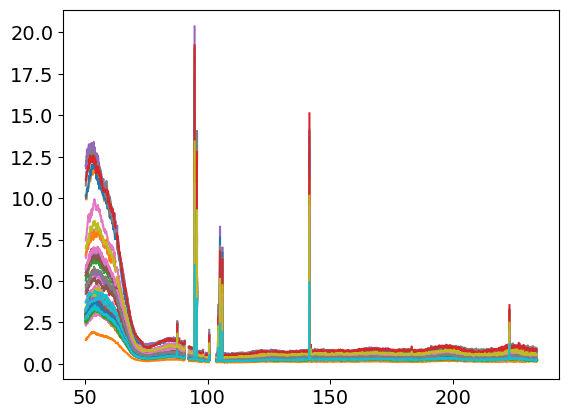

In [51]:
for g in total_gains_flagged_full:

    plt.plot(freq_range_reduced/1e6, np.abs(total_gains_flagged_full[g][0,:]), label="Gleam only")
    # plt.plot(np.abs(total_gains_full[g][0,25:-1]),'*')
#     plt.plot(np.abs(total_gains_gleam[g][0,50:-1]), label="Gleam only")
    # plt.plot(np.abs(total_gains_full[g][1,:]),'*')

# plt.legend()    

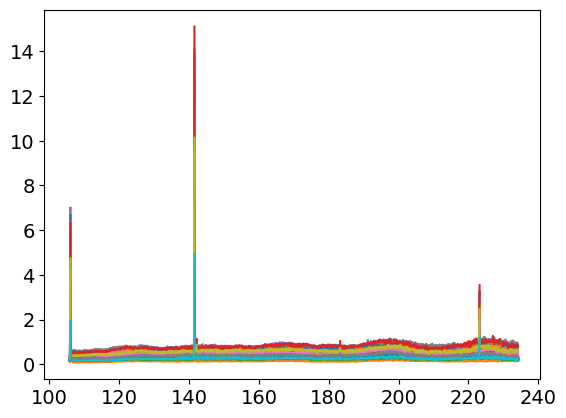

In [52]:
l=int(450)
for g in total_gains_flagged_full:

    plt.plot((freq_range_reduced/1e6)[l:-1], np.abs(total_gains_flagged_full[g][0,l:-1]), label="Gleam only")
    # plt.plot(np.abs(total_gains_full[g][0,25:-1]),'*')
#     plt.plot(np.abs(total_gains_gleam[g][0,50:-1]), label="Gleam only")
    # plt.plot(np.abs(total_gains_full[g][1,:]),'*')

# plt.legend()    

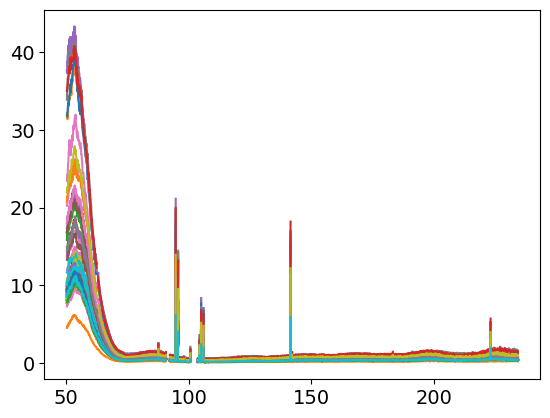

In [121]:
for g in total_gains_flagged_full:

    plt.plot(freq_range_reduced/1e6, np.abs(total_gains_flagged_gleam[g][0,:]), label="Gleam only")
    # plt.plot(np.abs(total_gains_full[g][0,25:-1]),'*')
#     plt.plot(np.abs(total_gains_gleam[g][0,50:-1]), label="Gleam only")
    # plt.plot(np.abs(total_gains_full[g][1,:]),'*')

# plt.legend()    

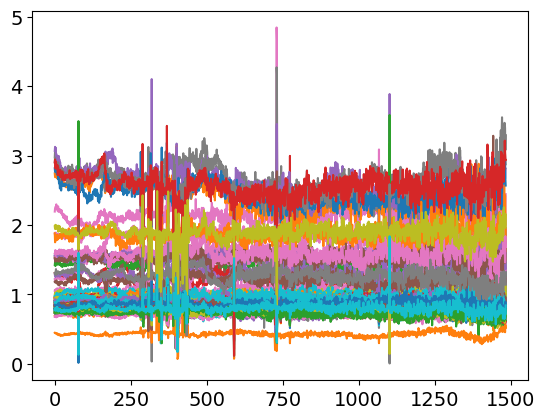

In [122]:
for g in total_gains_flagged_full:
    plt.plot(np.abs(sol.gains[g][0,50:-1]), label="Gleam only")
    # plt.plot(np.abs(total_gains_full[g][0,25:-1]),'*')
#     plt.plot(np.abs(total_gains_gleam[g][0,50:-1]), label="Gleam only")
    # plt.plot(np.abs(total_gains_full[g][1,:]),'*')

# plt.legend()    

In [ ]:
i=0
for g in total_gains_flagged_gleam:
    if i<10:
        plt.plot(freq_range, np.angle(total_gains_full[g][0,:]), label="Gleam only")
        # plt.plot(np.abs(total_gains_full[g][0,25:-1]),'*')
#         plt.plot(np.angle(total_gains_gleam[g][1,:]), label="Gleam only")
        # plt.plot(np.abs(total_gains_full[g][1,:]),'*')
    i+=1

In [ ]:
for g in total_gains_flagged_gleam:
    plt.plot(np.abs(total_gains_gleam[g][0,25:-1]),'*', label="Gleam only")
    # plt.plot(np.abs(total_gains_full[g][0,25:-1]),'*')
    plt.plot(np.abs(total_gains_gleam[g][1,25:-1]),'*', label="Gleam only")
    # plt.plot(np.abs(total_gains_full[g][1,25:-1]),'*')

# plt.legend()    

In [ ]:
# for g in total_gains_flagged_gleam:
plt.plot(np.abs(total_gains_flagged_gleam[g][0,25:-1]),'*', label="Gleam only")
plt.plot(np.abs(total_gains_flagged_full[g][0,25:-1]),'*')
plt.plot(np.abs(total_gains_flagged_gleam[g][1,25:-1]),'*', label="Gleam only")
plt.plot(np.abs(total_gains_flagged_full[g][1,25:-1]),'*')
plt.legend()    

In [ ]:
for g in total_gains_flagged_full:
    for t in range (2):
        plt.plot(np.abs(total_gains_flagged_full[g][t,:]),'*')

In [ ]:
for key in calibrated_data_final_gleam:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(data_flagged_redcal_gleam[key][0,:]))

In [ ]:
for key in calibrated_data_final_gleam:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(data_flagged_redcal_gleam[key][0,0:120]))

In [ ]:
for key in model_data:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(model_data[key][0,0:120]))

In [ ]:
for key in model_data:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(model_data_full[key][0,0:120]))

In [ ]:
for key in model_data:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(model_data_full[key][0,0:120]))

In [ ]:
for key in calibrated_data_final_gleam:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(data_flagged_redcal_full[key][0,:]))

In [ ]:
for key in calibrated_data_final_full:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(data_flagged_redcal_full[key][0,24:-1]))

In [ ]:
for key in calibrated_data_final_full:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(data_reduced[key][0,24:-1]))

In [ ]:
for key in calibrated_data_final_gleam:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(data_flagged_redcal_gleam[key][0,50:-1]))

In [ ]:
for key in calibrated_data_final_full:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(calibrated_data_final_full[key][0,:]))

In [ ]:
for key in calibrated_data_final_gleam:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(freq_range/1e6,np.abs(calibrated_data_final_gleam[key][0,:]))

In [ ]:
for key in calibrated_data_final_gleam:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(freq_range/1e6,np.abs(model_data[(key[0],key[1],'yy')][0,:]))

In [ ]:
for key in data_redcal:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(freq_range/1e6,np.abs(data_redcal[key][0,:]))

In [ ]:
for key in redcal_data:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(freq_range,np.abs(redcal_data[key][0,:]))

In [ ]:
data_redcal, total_gains_flagged_gleam=flag_data_and_gains(redcal_data, redcal_gains, rfi_flags[:,763:967])

In [ ]:
for key in data_redcal:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(data_redcal[key][0,:]))

In [ ]:
data_flagged_redcal_full, total_gains_flagged_full=flag_data_and_gains(calibrated_data_final_full, total_gains_full, rfi_flags)

In [ ]:
np.save(path_data+"gains/gains_abscal"+uvh5name[i]+".npy",total_gains_flagged_gleam)
np.save(path_data+"gains/gains_abscal"+uvh5name[i]+".npy",total_gains_flagged_full)

In [ ]:

hd_cal.update(data=data_flagged_redcal_full)
hd_cal.write_uvh5(path_data+"abs_calibrated_data_full_"+uvh5name[i], clobber=True)

hd_cal.update(data=data_flagged_redcal_gleam)
hd_cal.write_uvh5(path_data+"abs_calibrated_data_gleam_"+uvh5name[i], clobber=True)

In [ ]:
for g in total_gains_flagged_gleam:
    plt.plot(np.abs(total_gains_flagged_gleam[g][0,:]))

In [ ]:
for g in total_gains_flagged_full:
    plt.plot(np.abs(total_gains_flagged_full[g][0,:]))

In [ ]:
gains_total_all=[]
for g in total_gains_flagged_full:
    for t in range (2):
      gains_total_all.append(total_gains_flagged_full[g][t,:])
gains_total_all=np.array(gains_total_all)    

In [ ]:
gains_mean=np.mean(gains_total_all, axis=0)

for g in total_gains_flagged_full:
    plt.plot(np.abs(total_gains_flagged_full[g][0,:]))
plt.plot(np.abs(gains_mean),'k')    

In [ ]:


def delay_transform_gains(freq_range, total_gains):
    from scipy import signal
    tau=np.fft.fftshift(np.fft.fftfreq(len(freq_range),np.abs(freq_range[1]-freq_range[0])))*1e9
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=signal.windows.blackmanharris(len(tau))
    g0_delay=[]
    for g in total_gains:
        gain_clean=np.nan_to_num(total_gains[g], nan=0.0)
        for t in range (2):
            
            g0=np.fft.fftshift(np.abs(np.fft.fft(window*gain_clean[t,:])))[index]
            g0_delay.append(g0)
        
    g0_m=np.mean(np.array(g0_delay), axis=0)
    return tau_pos, g0_m/np.max(g0_m)


In [ ]:
tau, g0_gleam=delay_transform_gains(freq_range, total_gains_flagged_gleam)
tau, g0_full=delay_transform_gains(freq_range, total_gains_flagged_full)
plt.semilogy(tau,g0_gleam,'k')  
plt.semilogy(tau,g0_full,'g') 

In [ ]:
for key in data_flagged_redcal_full:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(data_flagged_redcal_full[key][0,:]))
        plt.    

In [ ]:
for key in data_flagged_redcal_full:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(freq_range,np.abs(data_flagged_redcal_gleam[key][0,:]))
    

In [ ]:
for key in data_flagged_redcal_full:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(data_flagged_redcal_gleam[key][0,:60]))